** Imports **

In [1]:
import numpy as np
import math

# !conda install -y -q numpy=1.26.4 scipy --update-deps
from joblib import Parallel, delayed

In [2]:
print("NumPy version:", np.__version__)


NumPy version: 1.26.4


** Generate samples of SPD(n) matrices **

They are generated from diagonalization (any such matrix is diagonalizable). The eigenvalues are uniformly samples from the interval [loc, loc + scale]. Then, it is conjugated by a random orthogonal matrix. The function generates num matrices with n = size.

In [2]:
### generate samples
from scipy.stats import ortho_group
# Use the most stable version of the numpy kernel, o/w scipy support breaks down

def gen_spd_sample(num, size, loc =2.,  scale=1.):

    if loc <1:
        raise ValueError('loc < 1 might result in numerical instability')
    
    matrices = []
    
    for i in range(num):
        diag_entries = np.random.uniform(loc, loc+scale, size) #ensure loc>0
        D = np.diag(diag_entries)
        Q = ortho_group.rvs(dim=size)
        matrix = np.einsum('ji,jj,jk->ik', Q, D, Q) #more efficient
        matrices.append(matrix)

    return np.array(matrices)

## Generate the betaprime kernel

The first function defines the cone gamma function where $N$ is the equivalent to the size parameter in the above function.
<!-- The betaprime_mat function simply generates the Gram matrix and uses parallelization. -->

The betaprime_mat function generates the Gram matrix and the parameter `parallel` can be set to either `True` or `False` to enable/disable parallelisation. 

In [15]:
### harmonic analysis kernels
import warnings
#compute special gamma function
def cone_gamma(N, z):
    log_prod = (N * (N - 1) / 2) * np.log(2 * np.pi)
    for k in range(N):
        log_prod += math.lgamma(z - k + 1)
    return np.exp(log_prod)

#compute kernel evaluation
def betaprime(A,B):
    
    N = A.shape[0]
    alpha = N
    
    if not N == B.shape[0]:
        raise ValueError('Matrices must have same size')
    # if not alpha > N-1:
    #     raise ValueError(f'alpha must be > {N-1}')
    if alpha < (N-1)/2:
        warnings.warn(f'alpha={alpha} is less than (N-1)/2={((N-1)/2):.2f}, which may not be sufficient for P.D-ness', UserWarning)
    
    gamma = cone_gamma(N, 2*alpha) #--> can cause overflow

    '''
    # Compute determinants
    _ , ldetA = np.linalg.slogdet(A)
    _ , ldetB = np.linalg.slogdet(B)
    _ , ldetAB = np.linalg.slogdet(A + B)
     
    dets = np.exp(alpha*(ldetA-2*ldetAB+ldetB))
    '''

    detA = np.linalg.det(A)
    detB = np.linalg.det(B)
    detAB = np.linalg.det(A+B)

    dets = (detA * detB /(detAB)**2)**alpha
    
    return gamma * dets

#compute kernel matrix using all CPU cores if parallel == True
def betaprime_mat(samples, alpha, parallel=True):
    # Validate inputs
    if not all(sample.shape[0] == sample.shape[1] for sample in samples):
        raise ValueError('All samples must be square matrices')
    if not all(sample.shape == samples[0].shape for sample in samples):
        raise ValueError('All samples must have the same dimensions')
    N = samples[0].shape[0]
    if alpha < (N-1)/2:
        warnings.warn(f'alpha={alpha} is less than (N-1)/2={((N-1)/2):.2f}, which may not be sufficient for P.D-ness', UserWarning)
    
    m = len(samples)
    kernel = np.zeros((m, m))
    
    if parallel == True:
        # Function to compute a single element of the kernel matrix
        def compute_entry(i, j):
            value = betaprime(samples[i], samples[j])
            return i, j, value
    
        # Use parallel processing to compute the upper triangular part
        results = Parallel(n_jobs=-1)(delayed(compute_entry)(i, j) for i in range(m) for j in range(i, m))
    
    else:
        # Do not use parallel processing to avoid overhead

        # initialize the results list with the size of the kernel matrix
        results = [0]*((m*(m+1))//2)
        idx = 0
        for i in range(m):
            for j in range(i, m):
                value = betaprime(samples[i], samples[j])
                results[idx] = (i, j, value)
                idx += 1
                # results[]((i, j, value))

    # Fill in the kernel matrix
    for i, j, value in results:
        kernel[i, j] = value
        kernel[j, i] = value  # Exploit symmetry
    
    return kernel


### Measuring the time taken to create the betaprime kernel matrix 

The experiment below measures the time taken to construct the betaprime kernel matrix, when the samples are taken randomly (as mentioned in the cells above) from the space of SPD matrices, when the parallelisation is turned on and off. 


In [18]:
# Test the function betaprime_mat if parallel == False and parallel == True
import timeit
if __name__ == "__main__":
    # Generate random SPD samples
    num_samples = 10000
    size = 10
    loc = 2.0
    scale = 1.0
    samples = gen_spd_sample(num_samples, size, loc, scale)

    # Set alpha for the kernel function
    alpha = 0.1

    # Measure time for parallel processing
    start_time_parallel = timeit.default_timer()
    kernel_matrix_parallel = betaprime_mat(samples, alpha, parallel=True)
    end_time_parallel = timeit.default_timer()
    # print("Kernel matrix (parallel):")
    # print(kernel_matrix_parallel)
    print(f"Time taken (parallel): {end_time_parallel - start_time_parallel:.6f} seconds")

    # Measure time for non-parallel processing
    start_time_no_parallel = timeit.default_timer()
    kernel_matrix_no_parallel = betaprime_mat(samples, alpha, parallel=False)
    end_time_no_parallel = timeit.default_timer()
    # print("Kernel matrix (no parallel):")
    # print(kernel_matrix_no_parallel)
    print(f"Time taken (no parallel): {end_time_no_parallel - start_time_no_parallel:.6f} seconds")

/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_99711/408381145.py:51: UserWarning: alpha=0.1 is less than (N-1)/2=4.50, which may not be sufficient for P.D-ness
  warnings.warn(f'alpha={alpha} is less than (N-1)/2={((N-1)/2):.2f}, which may not be sufficient for P.D-ness', UserWarning)


Time taken (parallel): 961.544330 seconds
Time taken (no parallel): 598.858292 seconds


In [19]:
import timeit

# Benchmark the cone_gamma function
execution_time = timeit.timeit('cone_gamma(5, 6)', globals=globals(), number=1000)
print(f"Average execution time over 1000 runs: {execution_time / 1000:.6f} seconds")

Average execution time over 1000 runs: 0.000006 seconds


### Matern kernels

The following cell creates an instance of the Matern kernel from the Azangulov package. Therefore, you need to install torch and geometric_kernels.
The normalize parameter ensures that $k(x,x)=1$ for all matrices $x \in \mathbb{GL}_n$. The nu-parameter defines the smoothness degree of the Matern kernel (which characterize stationary smooth-er GPs). Setting `'nu'` to `np.inf` creates an instance of the heat kernel. The evaluation using the K method always creates a Gram matrix.

In [20]:
# ### PDE kernels

# !conda install -y -q pytorch torchvision torchaudio cpuonly -c pytorch
# !pip install --upgrade geometric_kernels
import torch
import geometric_kernels
from geometric_kernels.spaces import SymmetricPositiveDefiniteMatrices
from geometric_kernels.kernels import MaternGeometricKernel

# size = 3
# space = SymmetricPositiveDefiniteMatrices(n=size)
# spd_kernel = MaternGeometricKernel(space, normalize=True, key = np.random.RandomState())

# #initialize params
# params = spd_kernel.init_params()
# params['nu']= np.array([1.]) #Matern kernel
# params['lengthscale']= np.array([1.])

# ### single evaluation of PDE kernel
# def pde_kernel(A,B):
#     return spd_kernel.K(params, A,B)[0][0] #unpack matrix

In [21]:
import torch
import geometric_kernels
from geometric_kernels.spaces import SymmetricPositiveDefiniteMatrices
from geometric_kernels.kernels import MaternGeometricKernel
class PDEKernel:
    def __init__(self, size=3, nu=1.0, lengthscale=1.0, normalize=True, random_state=None):
        if random_state is None:
            random_state = np.random.RandomState()
        self.space = SymmetricPositiveDefiniteMatrices(n=size)
        self.spd_kernel = MaternGeometricKernel(self.space, normalize=normalize, key=random_state)
        self.params = self.spd_kernel.init_params()
        self.params['nu'] = np.array([nu])
        self.params['lengthscale'] = np.array([lengthscale])

    def __call__(self, A, B):
        return self.spd_kernel.K(self.params, A, B)[0][0]

# Example usage:
# Now you can call pde_kernel(A, B) repeatedly


## Two-sample-test 

The following functions allow for kernel two-sample-test based on the paper by Gretton, Schölkopf, Smola, Borgwardt, Rasch.

In [22]:
#in lemma, that is funciton h(z1,z2)
def aid_func(f,x1,y1,x2,y2):
    return f(x1,x2) - f(x1,y2) - f(x2,y1) + f(y1,y2)


#adjusted to also allow efficient computation of empirical max
def aid_func_max(f,x1,y1,x2,y2):
    fxx = f(x1,x2)
    fxy = f(x1,y2)
    fyx = f(x2,y1)
    fyy = f(y1,y2)
    
    aid_result = fxx - fxy - fyx + fyy
    aid_max = max([fxx, fxy, fyx, fyy]) 
    
    return aid_result, aid_max


#general upper bound derived analytically. can be achieved for any range of eigenvals
def max_betaprime(N, alpha):
    
    gamma = cone_gamma(N, 2*alpha)
    return gamma/ (4**(N*alpha))

print(cone_gamma(6, 7)) # Testing the cone_gamma function

#test from lemma 6 
def kernel_test(func, level ,sampleA, sampleB):
    
    m = len(sampleA)
    N = sampleA[0].shape[0]
    
    if not len(sampleB)==m:
        raise ValueError('Samples must be of same size')

    
    #compute upper bound
    if func == betaprime:
        upper = max_betaprime(N,N)
    elif func == pde_kernel:
        upper = 1
        

    #compute test statistic
    aid_sum = 0
    
    for i in range(m):
        for j in range(i + 1, m):  # Avoid redundant computations
            val= aid_func(func, sampleA[i], sampleB[i], sampleA[j], sampleB[j])
            aid_sum += 2 * val  # Each (i, j) pair contributes twice
    
    test_stat = aid_sum/(m*(m-1)) #unbiased estimate
    print(f'Test statistic: {test_stat}')
    
    
    #compute acceptance region
    acceptance = np.sqrt(-np.log(level)) * (4*upper)/np.sqrt(m) #for H_0: samples from same distribution
    print(f'Acceptance bound is {acceptance}')

    #return test result
    if test_stat < acceptance:
        result = 'Fail to reject null hypothesis'

    if test_stat >= acceptance:
        result = 'Reject null hypothesis'
    
    return result 



### test from lemma 14 in ibid. (computationally more efficient)
def eff_kernel_test(func, level, sampleA, sampleB): # TODO: Extend it to non equal sample sizes
    
    m = int(np.floor(len(sampleA)/2))
    N = sampleA[0].shape[0]
    
    if not len(sampleB)==len(sampleA):
        raise ValueError('Samples must be of same size')

    
    #compute upper bound
    if func == betaprime:
        upper = max_betaprime(N,N)
    elif func == pde_kernel:
        upper = 1 #kernel normalized by k(x,x)=1 for all x --> k(x,y)<=1 by Cauchy-Schwartz

    
    #compute test statistic
    aid_sum = 0
    
    for i in range(m):
        aid_sum += aid_func(func, sampleA[2*i], sampleB[2*i], sampleA[2*i+1], sampleB[2*i+1])
        
    test_stat=aid_sum/m
    #print(f'Test statistic: {test_stat:.2e}')
    #compute acceptance region
    acceptance = np.sqrt(-np.log(level)) * (4*upper)/np.sqrt(m) #for H_0: samples from same distribution
    #print(f'Acceptance bound is {acceptance:.2e}.')
    # TODO: Use the correct acceptance region for the linear version of the MMD_k test

    
    #return test result
    if test_stat < acceptance:
        result = 0 #'Fail to reject null hypothesis'
    else:
        result = 1 #'Reject null hypothesis'
    
    return result #check that thrm 15 yields same acceptance region

1.1777003172786215e+23


### Perform the test

We run num_tests tests per sample pairing. the sample pairings are created as follows: we fix the eigenvalue range [locA, locA + scaleA] for sample A. Then we fix the eigenvalue range for sample B as [mult * locA, mult*locA + scaleB]. Then, we generate the two samples and run the efficient linear time two-sample-test and average the rejection rate to have a somewhat robust result for how the kernels perform.

In [25]:
#sample specs
num = 10000 #sample size # Initially set to 100
size = 10 #of matrices # Initially set to 3
diff_loc = 0
diff_scale = 0
locA = 30 #lower bound for eigenvals in sample A
#locB = locA + diff_loc
scaleA = 1 #spread in eigenvals
scaleB = scaleA + diff_scale

num_tests = 2 #tests run per parameter pairing
num_factors = 60 #number of different parameter pairings to test
bp_factors = np.linspace(.1,5,num_factors)
bp_results = np.zeros(len(bp_factors))

for i, mult in enumerate(bp_factors):
    #generate samples
    locB= locA * mult
    tests = np.zeros(num_tests)
    for j in range(num_tests):
        sampleA = gen_spd_sample(num, size, locA, scaleA)
        sampleB = gen_spd_sample(num, size, locB, scaleB)
        #test
        x = eff_kernel_test(betaprime, level = 0.05, sampleA= sampleA, sampleB= sampleB)
        tests[j]=x
    bp_results[i]=tests.mean()
    i+=1
    print(f'Factor {i} / {num_factors} done.')



Factor 1 / 60 done.
Factor 2 / 60 done.
Factor 3 / 60 done.
Factor 4 / 60 done.
Factor 5 / 60 done.
Factor 6 / 60 done.
Factor 7 / 60 done.
Factor 8 / 60 done.
Factor 9 / 60 done.
Factor 10 / 60 done.
Factor 11 / 60 done.
Factor 12 / 60 done.
Factor 13 / 60 done.
Factor 14 / 60 done.
Factor 15 / 60 done.
Factor 16 / 60 done.
Factor 17 / 60 done.
Factor 18 / 60 done.
Factor 19 / 60 done.
Factor 20 / 60 done.
Factor 21 / 60 done.
Factor 22 / 60 done.
Factor 23 / 60 done.
Factor 24 / 60 done.
Factor 25 / 60 done.
Factor 26 / 60 done.
Factor 27 / 60 done.
Factor 28 / 60 done.
Factor 29 / 60 done.
Factor 30 / 60 done.
Factor 31 / 60 done.
Factor 32 / 60 done.
Factor 33 / 60 done.
Factor 34 / 60 done.
Factor 35 / 60 done.
Factor 36 / 60 done.
Factor 37 / 60 done.
Factor 38 / 60 done.
Factor 39 / 60 done.
Factor 40 / 60 done.
Factor 41 / 60 done.
Factor 42 / 60 done.
Factor 43 / 60 done.
Factor 44 / 60 done.
Factor 45 / 60 done.
Factor 46 / 60 done.
Factor 47 / 60 done.
Factor 48 / 60 done.
F

In [13]:

num = 100 #sample size # Initially set to 100
size = 3 #of matrices # Initially set to 3
diff_loc = 0
diff_scale = 0
locA = 30 #lower bound for eigenvals in sample A
#locB = locA + diff_loc
scaleA = 1 #spread in eigenvals
scaleB = scaleA + diff_scale
pde_kernel = PDEKernel(size=size, nu=1.0, lengthscale=1.0)
num_tests = 2 #tests run per parameter pairing
num_factors = 60 #number of different parameter pairings to test
pde_factors = np.linspace(.1,5,num_factors)
pde_results = np.zeros(len(pde_factors))

for i, mult in enumerate(pde_factors):
    #generate samples
    locB= locA * mult
    tests = np.zeros(num_tests)
    for j in range(num_tests):
        sampleA = gen_spd_sample(num, size, locA, scaleA)
        sampleB = gen_spd_sample(num, size, locB, scaleB)
        #test
        x = eff_kernel_test(pde_kernel, level = 0.05, sampleA= sampleA, sampleB= sampleB)
        tests[j]=x
    pde_results[i]=tests.mean()
    i+=1
    print(f'Factor {i} / {num_factors} done.')

Factor 1 / 60 done.
Factor 2 / 60 done.
Factor 3 / 60 done.
Factor 4 / 60 done.
Factor 5 / 60 done.
Factor 6 / 60 done.
Factor 7 / 60 done.
Factor 8 / 60 done.
Factor 9 / 60 done.
Factor 10 / 60 done.
Factor 11 / 60 done.
Factor 12 / 60 done.
Factor 13 / 60 done.
Factor 14 / 60 done.
Factor 15 / 60 done.
Factor 16 / 60 done.
Factor 17 / 60 done.
Factor 18 / 60 done.
Factor 19 / 60 done.
Factor 20 / 60 done.
Factor 21 / 60 done.
Factor 22 / 60 done.
Factor 23 / 60 done.
Factor 24 / 60 done.
Factor 25 / 60 done.
Factor 26 / 60 done.
Factor 27 / 60 done.
Factor 28 / 60 done.
Factor 29 / 60 done.
Factor 30 / 60 done.
Factor 31 / 60 done.
Factor 32 / 60 done.
Factor 33 / 60 done.
Factor 34 / 60 done.
Factor 35 / 60 done.
Factor 36 / 60 done.
Factor 37 / 60 done.
Factor 38 / 60 done.
Factor 39 / 60 done.
Factor 40 / 60 done.
Factor 41 / 60 done.
Factor 42 / 60 done.
Factor 43 / 60 done.
Factor 44 / 60 done.
Factor 45 / 60 done.
Factor 46 / 60 done.
Factor 47 / 60 done.
Factor 48 / 60 done.
F

### Plot the results

We plot the results and save them as csv file. To make the plots prettier, we use Gaussian smoothing.

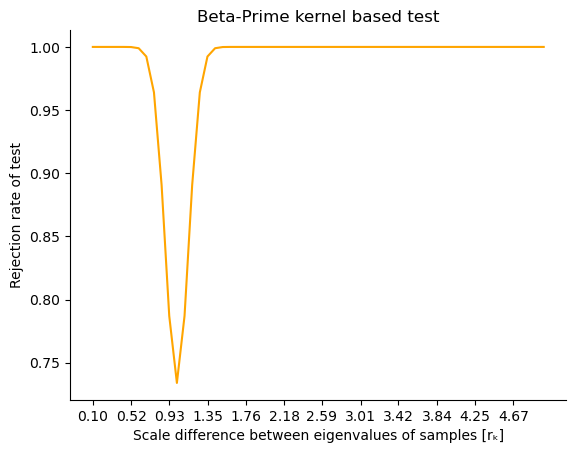

    eigenvalue_scale_ratio  rejection_rate
0                 0.100000             1.0
1                 0.183051             1.0
2                 0.266102             1.0
3                 0.349153             1.0
4                 0.432203             1.0
5                 0.515254             1.0
6                 0.598305             1.0
7                 0.681356             1.0
8                 0.764407             1.0
9                 0.847458             1.0
10                0.930508             1.0
11                1.013559             0.0
12                1.096610             1.0
13                1.179661             1.0
14                1.262712             1.0
15                1.345763             1.0
16                1.428814             1.0
17                1.511864             1.0
18                1.594915             1.0
19                1.677966             1.0
20                1.761017             1.0
21                1.844068             1.0
22         

In [26]:
### plotting test behaviour
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# kernel='Beta-prime' #or 'PDE' for PDE kernel
kernel = 'Beta-Prime'

#gaussian smoothing
if kernel == 'Beta-Prime':
    factors_gau = bp_factors
    results_gau = bp_results
elif kernel == 'PDE':
    factors_gau = pde_factors
    results_gau = pde_results
# results_gau = results
smooth_gau = gaussian_filter1d(results_gau, sigma=1.5)

#plot
fig, ax = plt.subplots()

ax.plot(factors_gau, smooth_gau, color='orange')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(kernel +' kernel based test')
ax.set_xlabel('Scale difference between eigenvalues of samples [r\u2096]')
ax.set_ylabel('Rejection rate of test')
ax.set_xticks(np.round(factors_gau[::5],2))
# plt.savefig('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/test_results_'+kernel+f'_factors{num_factors}_scale{locA}_numtests{num_tests}.svg', format='svg', dpi=300)
plt.show()

#save test results
factors_series = pd.Series(factors_gau)
results_series = pd.Series(results_gau)
test_results = pd.concat([factors_series, results_series], axis=1)
test_results.columns = ['eigenvalue_scale_ratio','rejection_rate']
print(test_results)
# test_results.to_csv('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/test_results_'+kernel +f'_factors{num_factors}_scale{locA}_numtests{num_tests}.csv')


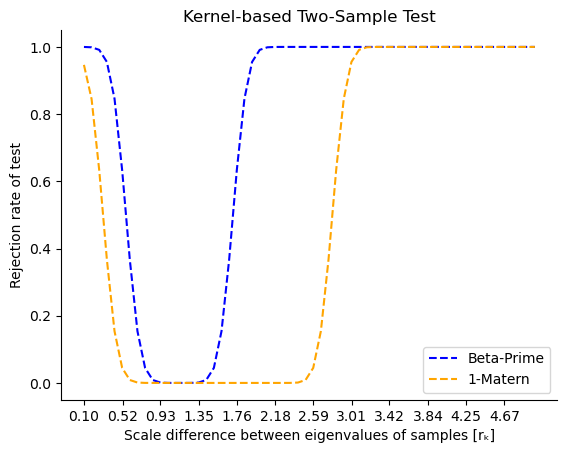

In [21]:
# Plot both PDE and Beta-prime kernel test results in the same plot
# Gaussian smoothing for both results
bp_smooth = gaussian_filter1d(bp_results, sigma=1.5)
pde_smooth = gaussian_filter1d(pde_results, sigma=1.5)

fig, ax = plt.subplots()
ax.plot(bp_factors, bp_smooth, label='Beta-Prime', color='blue', linestyle='--')
ax.plot(pde_factors, pde_smooth, label='1-Matern', color='orange', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Kernel-based Two-Sample Test')
ax.set_xlabel('Scale difference between eigenvalues of samples [r\u2096]')
ax.set_ylabel('Rejection rate of test')
ax.set_xticks(np.round(bp_factors[::5], 2))
ax.legend()
plt.savefig('./TwoSampleTestResults.svg', format='svg', dpi=1600)
plt.show()
